# SWOT along-track SSH spectra in 2°×2° boxes — Parallel version

Same goal as the serial notebook, but each granule file is processed in its own worker process using `concurrent.futures.ProcessPoolExecutor`. The aggregation and plotting steps are identical.

**Why processes, not threads?**  
The per-pixel-column FFT loops in `compute_swath_spectra` are Python loops (GIL-bound), and the underlying HDF5/netCDF4 library is not thread-safe for concurrent reads. Separate processes avoid both problems at the cost of inter-process communication overhead, which is negligible here since only the compact `SegmentSpectrum` dataclasses (small numpy arrays) cross the process boundary.

**`if __name__ == "__main__"` guard:**  
On Windows (and when using the default `spawn` start method on macOS), `ProcessPoolExecutor` re-imports the notebook's top-level module in each worker. All parallelism must therefore live inside a `if __name__ == "__main__":` guard **or** (as here) inside a plain function called only after all imports are complete. Jupyter handles this correctly on Linux (fork start method); on Windows/macOS set `mp_context="spawn"` explicitly (see cell below).

## 0. Imports

In [1]:
import glob
import os
import multiprocessing
import warnings
from collections import defaultdict
from concurrent.futures import ProcessPoolExecutor, as_completed
from pathlib import Path

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe
from tqdm.auto import tqdm

from swot_analysis import compute_pass_spectra
from swot_analysis.swot_alongtrack_spectra import SegmentSpectrum

## 1. Configuration

In [2]:
# ── Input files ──────────────────────────────────────────────────────────────
DATA_DIR = '/Users/zoecas/Documents/data/'
DATA_SUBDIR = "SWOT_L2_LR_SSH_D_D-20260702_095005/" # directory containing Expert .nc files
FILE_PATTERN = "SWOT_L2_LR_SSH_Expert_*.nc"

# ── Region of interest ───────────────────────────────────────────────────────
LAT_MIN, LAT_MAX = 30.0, 60.0
LON_MIN, LON_MAX = 280.0, 360.0

# ── Spectral parameters ───────────────────────────────────────────────────────
SEGMENT_LENGTH_KM = 250.0
OVERLAP           = 0.5
MAX_GAP_FRACTION  = 0.25

# ── Box size ─────────────────────────────────────────────────────────────────
BOX_DEG = 2.0

# ── Expert-product variable name ─────────────────────────────────────────────
SSH_VAR = "ssha_karin_2"

# ── Parallelism ───────────────────────────────────────────────────────────────
# None → use all available CPUs.  Set to e.g. 8 to cap usage.
N_WORKERS = None
# On macOS / Windows change to "spawn" to avoid fork-related HDF5 crashes:
MP_CONTEXT = "fork"    # "fork" | "spawn" | "forkserver"

print(f"Available CPUs: {multiprocessing.cpu_count()}")
print(f"Workers to use: {N_WORKERS or multiprocessing.cpu_count()}")

Available CPUs: 8
Workers to use: 8


## 2. Worker function

`process_one_file` runs in a **child process**: it loads one Expert granule, runs the spectral computation, filters segments to the region of interest, and returns a plain Python list of `SegmentSpectrum` dataclasses. `SegmentSpectrum` holds only numpy arrays, floats, and strings — all picklable — so it crosses the process boundary without serialisation issues.

Any exception is caught and returned as a `(filepath, error_string)` tuple so one bad granule never kills the entire batch.

In [5]:
def load_swot_l2_expert(filepath: str, ssh_var: str = "ssha_karin_2", HRET: bool = True) -> dict:
    """Expert-product loader (same as serial notebook)."""
    import numpy as np           # re-import inside worker process
    import xarray as xr

    ds = xr.open_dataset(filepath)
    if HRET:
        ssha = (ds[ssh_var]+ds["height_cor_xover"]+ds["internal_tide_hret"]).values.astype(float)
    else:
        ssha = (ds[ssh_var]+ds["height_cor_xover"]).values.astype(float)
    

    for qual_name in (f"{ssh_var}_qual", "ssha_karin_2_qual", "ssh_karin_2_qual"):
        if qual_name in ds.variables:
            qual = ds[qual_name].values
            ssha = np.where(qual == 0, ssha, np.nan)
            break

    for scf_name in ("ancillary_surface_classification_flag", "surface_classification_flag"):
        if scf_name in ds.variables:
            scf = ds[scf_name].values
            ssha = np.where(scf == 0, ssha, np.nan)
            break

    if "surface_type" in ds.variables:
        ssha = np.where(ds["surface_type"].values == 0, ssha, np.nan)

    lat = ds["latitude"].values.astype(float)
    lon = ds["longitude"].values.astype(float)
    xt  = ds["cross_track_distance"].values.astype(float)
    ds.close()
    return {"ssha": ssha, "latitude": lat, "longitude": lon, "cross_track_distance": xt}


def process_one_file(
    filepath: str,
    ssh_var: str,
    segment_length_km: float,
    overlap: float,
    max_gap_fraction: float,
    lat_min: float, lat_max: float,
    lon_min: float, lon_max: float,
):
    """
    Worker function: process a single SWOT Expert granule.

    Returns either:
      (granule_stem: str, segments: list[SegmentSpectrum], wavenumber: np.ndarray)
    or, on any exception:
      (filepath: str, error: str, None)
    """
    # These imports happen in the worker process (required for spawn/forkserver).
    from swot_analysis import compute_pass_spectra  # noqa: PLC0415

    try:
        data = load_swot_l2_expert(filepath, ssh_var=ssh_var)
    except Exception as exc:
        return (filepath, f"load error: {exc}", None)

    try:
        result = compute_pass_spectra(
            ssha=data["ssha"],
            latitude=data["latitude"],
            longitude=data["longitude"],
            cross_track_distance=data["cross_track_distance"],
            segment_length_km=segment_length_km,
            overlap=overlap,
            max_gap_fraction=max_gap_fraction,
        )
    except Exception as exc:
        return (filepath, f"spectra error: {exc}", None)

    granule_name = Path(filepath).stem
    kept = []
    wavenumber = None
    for swath_name, res in result.items():
        if res.n_segments_used == 0:
            continue
        if wavenumber is None:
            wavenumber = res.wavenumber
        for seg in res.segments:
            if (lat_min <= seg.lat_mean <= lat_max and
                    lon_min <= seg.lon_mean <= lon_max):
                seg._granule = granule_name   # attach provenance
                kept.append(seg)
            else:
                continue

    return (granule_name, kept, wavenumber)

## 3. Helper functions (identical to serial notebook)

In [6]:
def segments_to_dataset(all_segments: list, wavenumber: np.ndarray) -> xr.Dataset:
    if not all_segments:
        raise ValueError("No segments to pack.")
    psd = np.stack([s.psd for s in all_segments], axis=0)
    return xr.Dataset(
        data_vars=dict(
            psd=(["segment", "wavenumber"], psd,
                 {"long_name": "Along-track SSH(A) PSD", "units": "m^2 / (cycles/km)"}),
            lat_mean=(["segment"], [s.lat_mean for s in all_segments], {"units": "degrees_north"}),
            lat_min=(["segment"], [s.lat_min  for s in all_segments], {"units": "degrees_north"}),
            lat_max=(["segment"], [s.lat_max  for s in all_segments], {"units": "degrees_north"}),
            lon_mean=(["segment"], [s.lon_mean for s in all_segments], {"units": "degrees_east"}),
            n_pixels_used=(["segment"], [s.n_pixels_used  for s in all_segments]),
            valid_fraction=(["segment"], [s.valid_fraction for s in all_segments]),
            swath=(["segment"],   [s.swath    for s in all_segments]),
            granule=(["segment"], [s._granule  for s in all_segments]),
        ),
        coords=dict(
            wavenumber=("wavenumber", wavenumber, {"units": "cycles/km"}),
            segment=("segment", np.arange(len(all_segments))),
        ),
    )


def build_box_dataset(ds_segments: xr.Dataset, box_deg: float = 2.0) -> xr.Dataset:
    lat     = ds_segments["lat_mean"].values
    lon     = ds_segments["lon_mean"].values
    lat_idx = np.floor(lat / box_deg).astype(int)
    lon_idx = np.floor(lon / box_deg).astype(int)

    box_to_segs = defaultdict(list)
    for i, key in enumerate(zip(lat_idx, lon_idx)):
        box_to_segs[key].append(i)

    psd_all   = ds_segments["psd"].values
    wavenumber = ds_segments["wavenumber"].values
    rows_lat, rows_lon, rows_n, rows_psd = [], [], [], []
    li_out, loi_out = [], []

    for (li, loi), idxs in sorted(box_to_segs.items()):
        rows_psd.append(np.nanmean(psd_all[idxs, :], axis=0))
        rows_n.append(len(idxs))
        rows_lat.append((li  + 0.5) * box_deg)
        rows_lon.append((loi + 0.5) * box_deg)
        li_out.append(li); loi_out.append(loi)

    return xr.Dataset(
        data_vars=dict(
            mean_psd=(["box", "wavenumber"], np.stack(rows_psd, axis=0),
                      {"long_name": "Box-mean SSH(A) PSD", "units": "m^2 / (cycles/km)"}),
            n_segments=(["box"], rows_n),
            lat_center=(["box"], rows_lat, {"units": "degrees_north"}),
            lon_center=(["box"], rows_lon, {"units": "degrees_east"}),
            lat_idx=(["box"], li_out),
            lon_idx=(["box"], loi_out),
        ),
        coords=dict(
            wavenumber=("wavenumber", wavenumber, {"units": "cycles/km"}),
            box=("box", np.arange(len(rows_n))),
        ),
        attrs=dict(box_size_deg=box_deg),
    )

## 4. Parallel processing

`ProcessPoolExecutor.submit` dispatches one file per task; `as_completed` lets us update a progress bar as results arrive in completion order (not submission order), and catches any worker exception without aborting the pool.

In [8]:
filepaths = sorted(glob.glob(os.path.join(DATA_DIR,DATA_SUBDIR, FILE_PATTERN)))
print(f"{len(filepaths)} Expert granule files found.")

# Fixed kwargs passed to every worker call
worker_kwargs = dict(
    ssh_var=SSH_VAR,
    segment_length_km=SEGMENT_LENGTH_KM,
    overlap=OVERLAP,
    max_gap_fraction=MAX_GAP_FRACTION,
    lat_min=LAT_MIN, lat_max=LAT_MAX,
    lon_min=LON_MIN, lon_max=LON_MAX,
)

all_segments  = []
wavenumber    = None
skipped       = []
n_files_ok    = 0

ctx = multiprocessing.get_context(MP_CONTEXT)

with ProcessPoolExecutor(max_workers=N_WORKERS, mp_context=ctx) as pool:
    futures = {
        pool.submit(process_one_file, fp, **worker_kwargs): fp
        for fp in filepaths
    }

    with tqdm(total=len(futures), desc="Processing granules", unit="file") as pbar:
        for future in as_completed(futures):
            fp = futures[future]
            try:
                name, payload, wk = future.result()
            except Exception as exc:
                # Unexpected crash in the worker (rare; payload exceptions
                # are returned as tuples, not raised)
                skipped.append((fp, f"unhandled worker exception: {exc}"))
                pbar.update(1)
                continue

            if isinstance(payload, str):
                # Worker returned an error string
                skipped.append((fp, payload))
            else:
                # payload is a list of SegmentSpectrum
                all_segments.extend(payload)
                if wavenumber is None and wk is not None:
                    wavenumber = wk
                n_files_ok += 1

            pbar.update(1)

print(f"\nDone. {n_files_ok}/{len(filepaths)} files processed successfully.")
print(f"{len(all_segments)} segments retained in region.")
if skipped:
    print(f"{len(skipped)} file(s) skipped:")
    for fp, err in skipped:
        print(f"  {Path(fp).name}: {err}")

71 Expert granule files found.


Processing granules:   0%|          | 0/71 [00:00<?, ?file/s]


Done. 71/71 files processed successfully.
1048 segments retained in region.


## 5. Build segment and box datasets

In [9]:
if not all_segments:
    raise RuntimeError("No segments retained — check region bounds, "
                        "file pattern, and SSH variable name.")

ds_segments = segments_to_dataset(all_segments, wavenumber)
print(f"Segment dataset: {ds_segments.sizes}")

ds_boxes = build_box_dataset(ds_segments, box_deg=BOX_DEG)
print(f"Box dataset: {ds_boxes.sizes['box']} boxes")
ds_boxes

Segment dataset: Frozen({'segment': 1048, 'wavenumber': 63})
Box dataset: 272 boxes


<xarray.Dataset> Size: 151kB
Dimensions:     (box: 272, wavenumber: 63)
Coordinates:
  * box         (box) int64 2kB 0 1 2 3 4 5 6 7 ... 265 266 267 268 269 270 271
  * wavenumber  (wavenumber) float64 504B 0.0 0.003998 ... 0.2439 0.2479
Data variables:
    mean_psd    (box, wavenumber) float64 137kB 0.07223 0.1598 ... 1.279e-05
    n_segments  (box) int64 2kB 2 3 3 2 3 1 3 3 1 3 4 ... 3 3 3 1 1 2 2 4 3 3 2
    lat_center  (box) float64 2kB 31.0 31.0 31.0 31.0 ... 59.0 59.0 59.0 59.0
    lon_center  (box) float64 2kB 281.0 283.0 285.0 287.0 ... 339.0 341.0 343.0
    lat_idx     (box) int64 2kB 15 15 15 15 15 15 15 15 ... 29 29 29 29 29 29 29
    lon_idx     (box) int64 2kB 140 141 142 143 144 145 ... 167 168 169 170 171
Attributes:
    box_size_deg:  2.0

## 6. Diagnostics

In [10]:
print("Segments per swath:")
for sw in ("left", "right"):
    n = int((ds_segments["swath"] == sw).sum())
    print(f"  {sw}: {n}")

unique_granules = len(np.unique(ds_segments["granule"].values))
print(f"\nUnique granules contributing segments: {unique_granules}")
print(f"Boxes with ≥ 5  segments: {int((ds_boxes['n_segments'] >= 5).sum())}")
print(f"Boxes with ≥ 10 segments: {int((ds_boxes['n_segments'] >= 10).sum())}")
print(f"Max segments in a box:    {int(ds_boxes['n_segments'].max())}")

Segments per swath:
  left: 585
  right: 463

Unique granules contributing segments: 54
Boxes with ≥ 5  segments: 88
Boxes with ≥ 10 segments: 12
Max segments in a box:    12


## 7. Map: number of segments per box

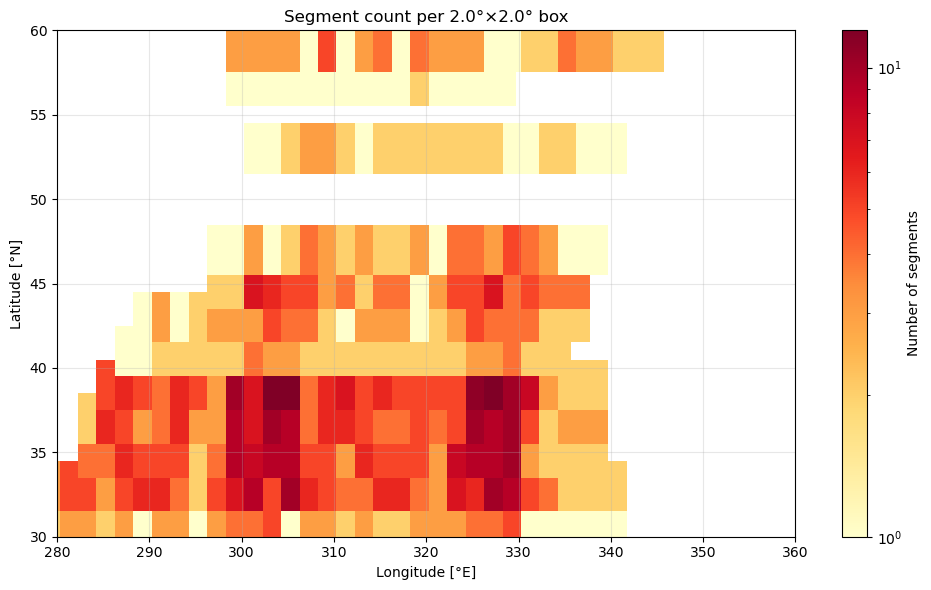

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(
    ds_boxes["lon_center"].values,
    ds_boxes["lat_center"].values,
    c=ds_boxes["n_segments"].values,
    s=(BOX_DEG * 60) ** 1.5,
    marker="s",
    cmap="YlOrRd",
    norm=mcolors.LogNorm(vmin=1, vmax=float(ds_boxes["n_segments"].max())),
    edgecolors="none",
)
plt.colorbar(sc, ax=ax, label="Number of segments")
ax.set_xlim(LON_MIN, LON_MAX); ax.set_ylim(LAT_MIN, LAT_MAX)
ax.set_xlabel("Longitude [°E]"); ax.set_ylabel("Latitude [°N]")
ax.set_title(f"Segment count per {BOX_DEG}°×{BOX_DEG}° box")
ax.grid(True, alpha=0.3); fig.tight_layout()

## 8. Map: integrated spectral energy per box

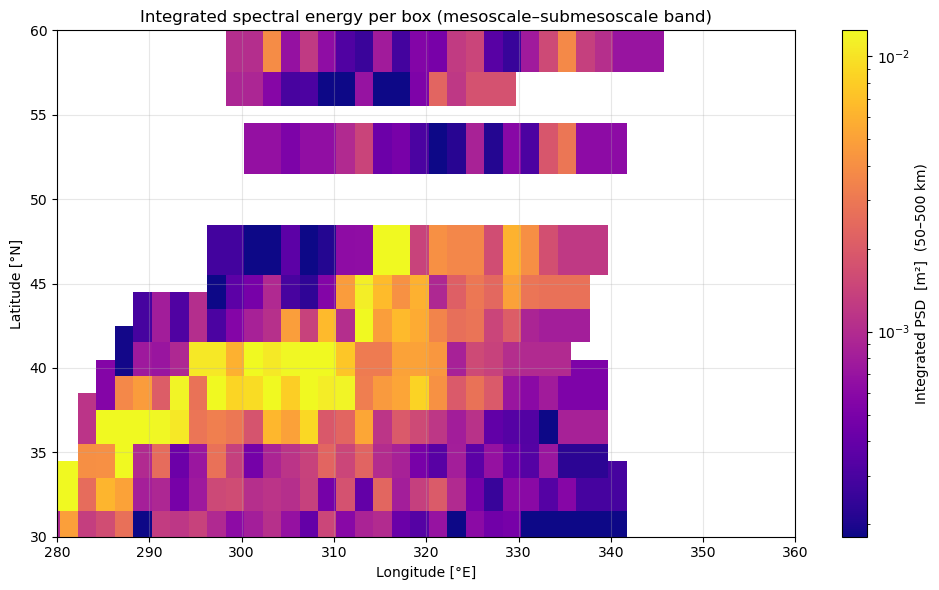

In [12]:
K_MIN, K_MAX = 1/500, 1/50  # cycles/km

k      = ds_boxes["wavenumber"].values
k_mask = (k >= K_MIN) & (k <= K_MAX)
dk     = np.gradient(k)
energy = np.nansum(ds_boxes["mean_psd"].values[:, k_mask] * dk[k_mask], axis=1)

fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(
    ds_boxes["lon_center"].values,
    ds_boxes["lat_center"].values,
    c=energy,
    s=(BOX_DEG * 60) ** 1.5,
    marker="s",
    cmap="plasma",
    norm=mcolors.LogNorm(vmin=np.nanpercentile(energy, 5),
                          vmax=np.nanpercentile(energy, 95)),
    edgecolors="none",
)
plt.colorbar(sc, ax=ax, label=f"Integrated PSD  [m²]  ({1/K_MAX:.0f}–{1/K_MIN:.0f} km)")
ax.set_xlim(LON_MIN, LON_MAX); ax.set_ylim(LAT_MIN, LAT_MAX)
ax.set_xlabel("Longitude [°E]"); ax.set_ylabel("Latitude [°N]")
ax.set_title("Integrated spectral energy per box (mesoscale–submesoscale band)")
ax.grid(True, alpha=0.3); fig.tight_layout()

## 9. Spectra: mean PSD per box, coloured by latitude

88 boxes with ≥ 5 segments


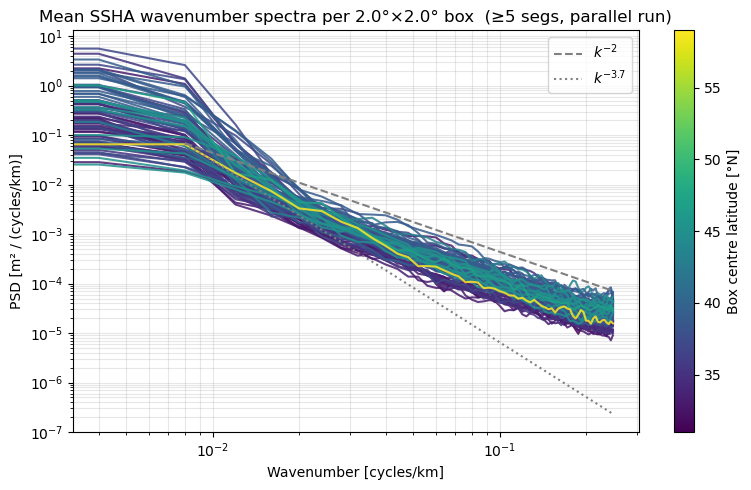

In [13]:
MIN_SEGMENTS_PER_BOX = 5

good = ds_boxes.where(ds_boxes["n_segments"] >= MIN_SEGMENTS_PER_BOX, drop=True)
print(f"{good.sizes['box']} boxes with ≥ {MIN_SEGMENTS_PER_BOX} segments")

lat_vals = good["lat_center"].values
norm = plt.Normalize(vmin=lat_vals.min(), vmax=lat_vals.max())
cmap = plt.get_cmap("viridis")

fig, ax = plt.subplots(figsize=(8, 5))
for i in range(good.sizes["box"]):
    box = good.isel(box=i)
    ax.loglog(box["wavenumber"], box["mean_psd"],
              color=cmap(norm(float(box["lat_center"]))),
              lw=1.5, alpha=0.85)

k_ref = good["wavenumber"].values[2:]
psd0  = float(good["mean_psd"].isel(box=0).values[2])
k0    = k_ref[0]
for exp, ls in ((-2, "--"), (-11/3, ":")):
    lbl = f"$k^{{{exp:.2g}}}$".replace("-3.67", "-11/3")
    ax.loglog(k_ref, psd0 * (k_ref / k0) ** exp, ls, color="gray", label=lbl)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label="Box centre latitude [°N]")
ax.set_xlabel("Wavenumber [cycles/km]")
ax.set_ylabel("PSD [m² / (cycles/km)]")
ax.set_title(f"Mean SSHA wavenumber spectra per {BOX_DEG}°×{BOX_DEG}° box  "
             f"(≥{MIN_SEGMENTS_PER_BOX} segs, parallel run)")
ax.legend(); ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()

## 10. Save results

In [ ]:
# ds_segments.to_netcdf("swot_expert_segments_parallel.nc")
# ds_boxes.to_netcdf("swot_expert_box_spectra_parallel.nc")